In [25]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import norm
import time

Keys inside file: ['imageAC']


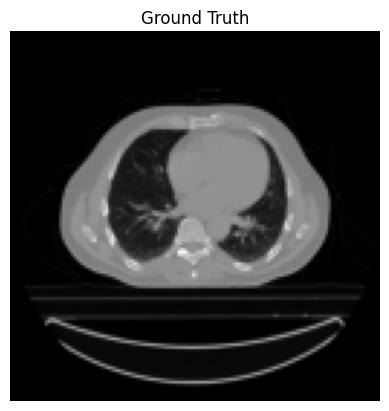

Image size: (128, 128)


In [26]:
file_path = 'C:/Users/rishi/.vscode/MIC/Image_Reconstruction_mic/data/assignmentMathImagingRecon_chestCT.mat'

with h5py.File(file_path, 'r') as f:
    print("Keys inside file:", list(f.keys()))
    
    gt = np.array(f['imageAC'])  

gt = gt.T  
if gt.shape[0] > 128:
    from skimage.transform import resize
    gt = resize(gt, (128,128), anti_aliasing=True)

N = gt.shape[0]
x_true = gt.flatten()

plt.imshow(gt, cmap='gray')
plt.title("Ground Truth")
plt.axis('off')
plt.show()

print("Image size:", gt.shape)

In [27]:
def build_system_matrix(N, angles_deg, ds=1.0):
    """
    Build sparse system matrix A for an N x N image and projection angles in degrees.
    - N: image width (assumes square)
    - angles_deg: array-like of angles in degrees (e.g. np.arange(0,180,1))
    - ds: sampling step along ray (in pixels)
    Returns: A (csr_matrix) of shape (M, N*N) and t_vals (detector offsets)
    """
    coords = np.arange(N) - (N-1)/2.0
    t_vals = coords.copy()

    max_len = np.sqrt(2) * N  
    rows = []
    cols = []
    vals = []
    row_idx = 0

    for theta in angles_deg:
        th = np.deg2rad(theta)
        cos_t = np.cos(th); sin_t = np.sin(th)

        for t in t_vals:
            s_vals = np.arange(-max_len, max_len + ds, ds)
            x_line = t * cos_t - s_vals * sin_t
            y_line = t * sin_t + s_vals * cos_t

            xi = np.round(x_line + (N-1)/2.0).astype(int)
            yi = np.round(y_line + (N-1)/2.0).astype(int)

            valid_mask = (xi >= 0) & (xi < N) & (yi >= 0) & (yi < N)
            if not np.any(valid_mask):
                row_idx += 1
                continue
            pixels = set(zip(xi[valid_mask], yi[valid_mask]))

            for xpix, ypix in pixels:
                col = ypix * N + xpix  
                rows.append(row_idx)
                cols.append(col)
                vals.append(ds)  
            row_idx += 1

    A = csr_matrix((vals, (rows, cols)), shape=(row_idx, N*N), dtype=np.float32)
    return A, t_vals

In [28]:
x_true = gt.flatten().astype(np.float32)
theta = np.arange(0, 180, 1)
A, t_vals = build_system_matrix(N, theta, ds=1.0)
print("A shape:", A.shape, "nnz:", A.nnz)
b = A @ x_true
intensity_range = float(b.max() - b.min())
sigma = 0.05 * intensity_range
rng = np.random.default_rng(0)  
noise = rng.normal(0.0, sigma, size=b.shape).astype(np.float32)
b_noisy = b + noise

A shape: (23040, 16384) nnz: 2647088


In [29]:
print("b min/max:", b.min(), b.max(), "sigma:", sigma)

b min/max: 7.692105e-05 3522.665 sigma: 176.133251953125


In [30]:
def rrmse(x_true, x_est):
    return np.linalg.norm(x_true - x_est) / np.linalg.norm(x_true)

In [31]:
def myART(A, b, x_true=None, lam=0.3, ordering='sequential', max_iter=10, save_intermediate=True):

    M, P = A.shape
    x = np.zeros(P, dtype=np.float32)
    row_norms = np.array(A.power(2).sum(axis=1)).flatten() 
    row_norms[row_norms == 0] = 1.0

    rrmse_list = []
    saved_x = [] if save_intermediate else None

    for it in range(max_iter):
        if ordering == 'sequential':
            order = np.arange(M)
        elif ordering == 'random':
            order = np.random.default_rng(it).permutation(M)
        else:
            raise ValueError("Unknown ordering")

        for i in order:
            row = A.getrow(i)
            if row.nnz == 0:
                continue
            indices = row.indices     
            data = row.data.astype(np.float32)  
            ai_x = np.dot(data, x[indices])
            resid = float(b[i] - ai_x)
            x[indices] += (lam * resid / row_norms[i]) * data

        if x_true is not None:
            r = rrmse(x_true, x)
            rrmse_list.append(r)
            print(f"iter {it+1}/{max_iter}  RRMSE = {r:.6f}")
        else:
            rrmse_list.append(None)

        if save_intermediate:
            saved_x.append(x.copy())

    if save_intermediate:
        return x, rrmse_list, saved_x
    return x, rrmse_list

In [32]:
import matplotlib.pyplot as plt
import os

lambda_values = np.arange(0.1, 1.01, 0.1)
max_iter = 10
out_dir = "Q4_outputs"
os.makedirs(out_dir, exist_ok=True)

all_rrmse = {}

for lam in lambda_values:
    print("\n--- Running ART with lambda =", lam)
    x_rec, rrmse_list = myART(A, b_noisy, x_true=x_true, lam=lam, ordering='sequential', max_iter=max_iter, save_intermediate=False)
    all_rrmse[lam] = rrmse_list

    recon_img = x_rec.reshape((N, N))
    plt.imsave(os.path.join(out_dir, f"recon_lambda_{lam:.1f}.png"), recon_img, cmap='gray')
    print("saved:", os.path.join(out_dir, f"recon_lambda_{lam:.1f}.png"))


--- Running ART with lambda = 0.1
iter 1/10  RRMSE = 0.350741
iter 2/10  RRMSE = 0.261742
iter 3/10  RRMSE = 0.263718
iter 4/10  RRMSE = 0.289270
iter 5/10  RRMSE = 0.318949
iter 6/10  RRMSE = 0.347827
iter 7/10  RRMSE = 0.374802
iter 8/10  RRMSE = 0.399657
iter 9/10  RRMSE = 0.422504
iter 10/10  RRMSE = 0.443530
saved: Q4_outputs\recon_lambda_0.1.png

--- Running ART with lambda = 0.2
iter 1/10  RRMSE = 0.433814
iter 2/10  RRMSE = 0.373606
iter 3/10  RRMSE = 0.385869
iter 4/10  RRMSE = 0.420569
iter 5/10  RRMSE = 0.458981
iter 6/10  RRMSE = 0.494399
iter 7/10  RRMSE = 0.526300
iter 8/10  RRMSE = 0.554523
iter 9/10  RRMSE = 0.579989
iter 10/10  RRMSE = 0.603091
saved: Q4_outputs\recon_lambda_0.2.png

--- Running ART with lambda = 0.30000000000000004
iter 1/10  RRMSE = 0.513198
iter 2/10  RRMSE = 0.483890
iter 3/10  RRMSE = 0.501129
iter 4/10  RRMSE = 0.531689
iter 5/10  RRMSE = 0.566145
iter 6/10  RRMSE = 0.599340
iter 7/10  RRMSE = 0.630928
iter 8/10  RRMSE = 0.659475
iter 9/10  RRMS

In [33]:
print("A shape:", A.shape, "nnz:", A.nnz)
print("b length:", b.shape)
print("x_true norm:", np.linalg.norm(x_true))
b_test = A @ x_true
print("norm difference between computed b and original b:", np.linalg.norm(b_test - b))

A shape: (23040, 16384) nnz: 2647088
b length: (23040,)
x_true norm: 2677.0527
norm difference between computed b and original b: 0.0


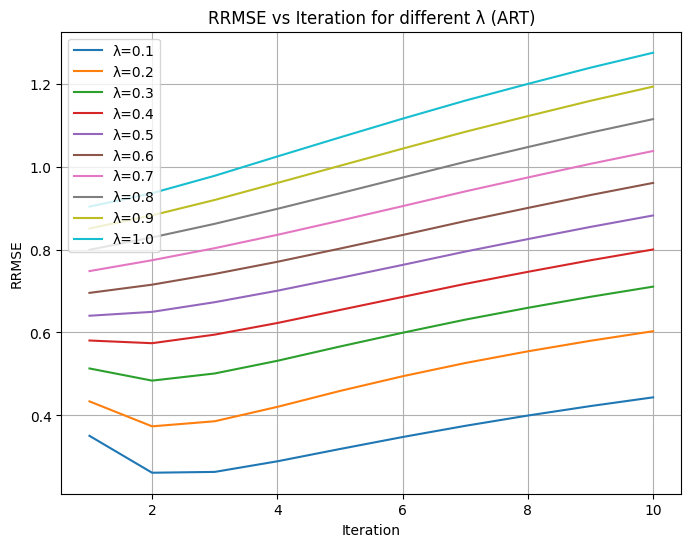

In [34]:
plt.figure(figsize=(8,6))
for lam in lambda_values:
    plt.plot(range(1, max_iter+1), all_rrmse[lam], label=f"λ={lam:.1f}")
plt.xlabel("Iteration")
plt.ylabel("RRMSE")
plt.title("RRMSE vs Iteration for different λ (ART)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(out_dir, "RRMSE_vs_iters.png"), dpi=200)
plt.show()